# Wine Style Clustering — 04: Visualisation

**Input:** `data/processed/wines_{red,white,rose}_clustered.csv`  
**Output:** `results/figures/04_*.png` — publication-ready charts

Contents:
1. UMAP — individual colour plots with labelled clusters
2. UMAP — combined overview (for article header)
3. Cluster cards — key descriptors + example wines
4. Cluster size comparison

---

## 0. Setup

In [3]:
import os
os.chdir(os.path.expanduser('~/Documents/wine-style-clustering'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results/figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom': False,
    'font.family': 'serif',
    'font.size': 11,
})

RED_PALETTE   = ['#C1392B', '#2980B9', '#27AE60', '#F39C12', '#8E44AD', '#16A085']
WHITE_PALETTE = ['#2C3E50', '#E67E22', '#2980B9', '#27AE60', '#8E44AD', '#C0392B']
ROSE_PALETTE  = ['#C0392B', '#8E44AD', '#E67E22']
NOISE_COLOR   = '#DDDDDD'

print('Ready.')


Ready.


## 1. Load data

In [4]:
df_red   = pd.read_csv('data/processed/wines_red_clustered.csv')
df_white = pd.read_csv('data/processed/wines_white_clustered.csv')
df_rose  = pd.read_csv('data/processed/wines_rose_clustered.csv')

print(f'Red:   {len(df_red):,} | White: {len(df_white):,} | Rosé: {len(df_rose):,}')

# Full labels
RED_LABELS = {
    0: 'Firm-structured, floral reds with a savoury, earthy core',
    1: 'Silky, red-fruited aromatics with forest floor and mineral depth',
    2: 'Dark, oak-framed power reds built on cassis and graphite',
    3: 'Spice-driven dark reds, approachable and food-ready',
    4: 'Bright, juicy, light reds with crunchy red fruit',
    5: 'Fresh, mineral, well-balanced reds with honest grip',
}
WHITE_LABELS = {
    0: 'Rich, mineral-driven whites with creamy orchard depth',
    1: 'Aromatic, fruit-expressive whites across the spectrum',
    2: 'Vibrant, tropical-citrus whites with herbal freshness',
    3: 'Full-bodied, generous whites with honeyed stone fruit weight',
    4: 'Fresh, florally aromatic whites with citrus-saline drive',
    5: 'Precise, mineral-citrus whites with electric acidity',
}
ROSE_LABELS = {
    0: 'Deep, structured rosés with dark fruit and tannic grip',
    1: 'Elegant, mineral pale rosés with floral lift and stone fruit',
    2: 'Fresh, vivid rosés with wild berry and citrus-saline snap',
}

# Key descriptors from manual characterisation
RED_DESCRIPTORS = {
    0: ['powdery tannins', 'dried herbs', 'violet', 'sour cherry', 'blood orange', 'balsamic', 'iron minerality'],
    1: ['silky tannins', 'wild strawberry', 'sous bois', 'blood orange', 'saline minerality', 'white pepper', 'forest floor'],
    2: ['cassis', 'graphite', 'cedarwood', 'dark chocolate', 'salty liquorice', 'tobacco', 'firm tannins'],
    3: ['blackberry', 'vanilla oak', 'black pepper', 'smoked meat', 'black olive', 'spiced plum', 'leather'],
    4: ['sour cherry', 'sappy', 'strawberry', 'amaro', 'vibrant acidity', 'soft tannins', 'floral'],
    5: ['chalky mineral', 'graphite', 'menthol', 'grippy tannins', 'garrigue', 'saline finish', 'black cherry'],
}
WHITE_DESCRIPTORS = {
    0: ['lemon curd', 'flinty reduction', 'saline minerality', 'toasted hazelnut', 'brioche', 'oyster shell', 'creamy texture'],
    1: ['peach', 'apricot', 'white flowers', 'beeswax', 'warm spice', 'almond', 'phenolic grip'],
    2: ['passion fruit', 'lime', 'gooseberry', 'elderflower', 'blackcurrant leaf', 'racy acidity', 'saline'],
    3: ['white peach', 'apricot', 'honeysuckle', 'oily texture', 'honey', 'almond', 'marzipan'],
    4: ['peach', 'jasmine', 'white blossom', 'saline', 'herbal', 'grapefruit pith', 'bright acidity'],
    5: ['lime', 'slate', 'petrol', 'piercing acidity', 'crushed stone', 'beeswax', 'cardamom'],
}
ROSE_DESCRIPTORS = {
    0: ['dark cherry', 'blackcurrant', 'garrigue', 'grippy tannins', 'bitter herbs', 'saline', 'concentrated'],
    1: ['strawberry', 'white peach', 'rose petal', 'saline minerality', 'silky texture', 'floral', 'elegant'],
    2: ['wild strawberry', 'watermelon', 'raspberry', 'grapefruit', 'racy acidity', 'citrus-saline', 'vibrant'],
}

# Short labels for legend
RED_SHORT   = {k: v.split(',')[0] for k, v in RED_LABELS.items()}
WHITE_SHORT = {k: v.split(',')[0] for k, v in WHITE_LABELS.items()}
ROSE_SHORT  = {k: v.split(',')[0] for k, v in ROSE_LABELS.items()}


Red:   8,783 | White: 8,364 | Rosé: 2,094


## 2. UMAP — individual colour plots

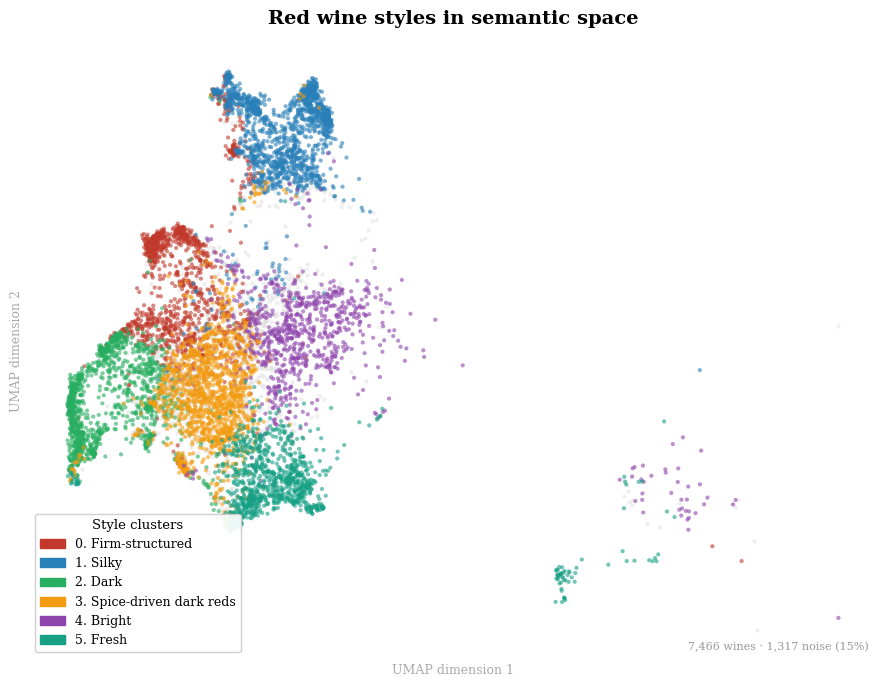

Saved: results/figures/04_umap_red.png


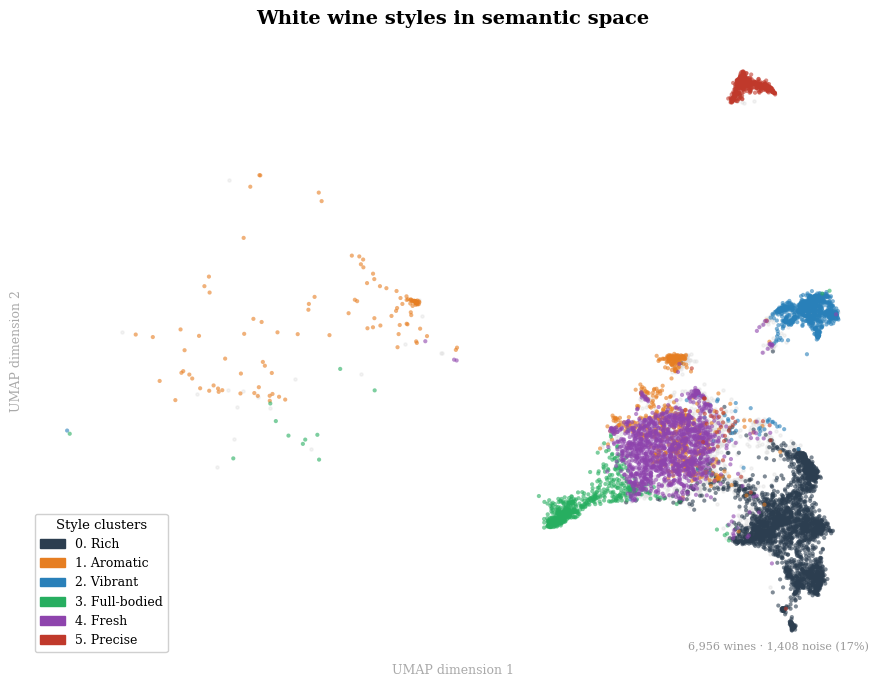

Saved: results/figures/04_umap_white.png


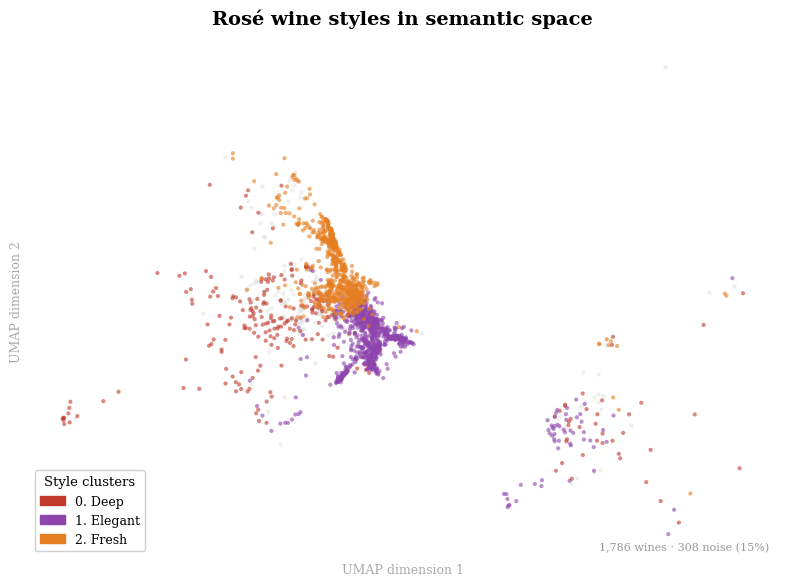

Saved: results/figures/04_umap_rose.png


In [5]:
def plot_umap_single(df, labels, short_labels, palette, title, fname, figsize=(9, 7)):
    fig, ax = plt.subplots(figsize=figsize)

    noise = df['cluster'] == -1
    ax.scatter(df.loc[noise, 'umap_x'], df.loc[noise, 'umap_y'],
               c=NOISE_COLOR, s=5, alpha=0.35, rasterized=True, zorder=1)

    handles = []
    for cluster_id, label in sorted(short_labels.items()):
        mask  = df['cluster'] == cluster_id
        color = palette[cluster_id % len(palette)]
        ax.scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                   c=color, s=9, alpha=0.6, rasterized=True, zorder=2, edgecolors='none')
        handles.append(mpatches.Patch(color=color, label=f'{cluster_id}. {label}'))

    ax.legend(handles=handles, loc='lower left', fontsize=9,
              frameon=True, framealpha=0.92, edgecolor='#ccc',
              title='Style clusters', title_fontsize=9.5)

    n_noise     = noise.sum()
    n_clustered = (~noise).sum()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.text(0.99, 0.01,
            f'{n_clustered:,} wines · {n_noise:,} noise ({n_noise/(n_noise+n_clustered)*100:.0f}%)',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#999')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('UMAP dimension 1', fontsize=9, color='#aaa')
    ax.set_ylabel('UMAP dimension 2', fontsize=9, color='#aaa')

    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


plot_umap_single(df_red,   RED_LABELS,   RED_SHORT,   RED_PALETTE,
                 'Red wine styles in semantic space', 'results/figures/04_umap_red.png')
plot_umap_single(df_white, WHITE_LABELS, WHITE_SHORT, WHITE_PALETTE,
                 'White wine styles in semantic space', 'results/figures/04_umap_white.png')
plot_umap_single(df_rose,  ROSE_LABELS,  ROSE_SHORT,  ROSE_PALETTE,
                 'Rosé wine styles in semantic space', 'results/figures/04_umap_rose.png', figsize=(8, 6))


## 3. UMAP — combined overview

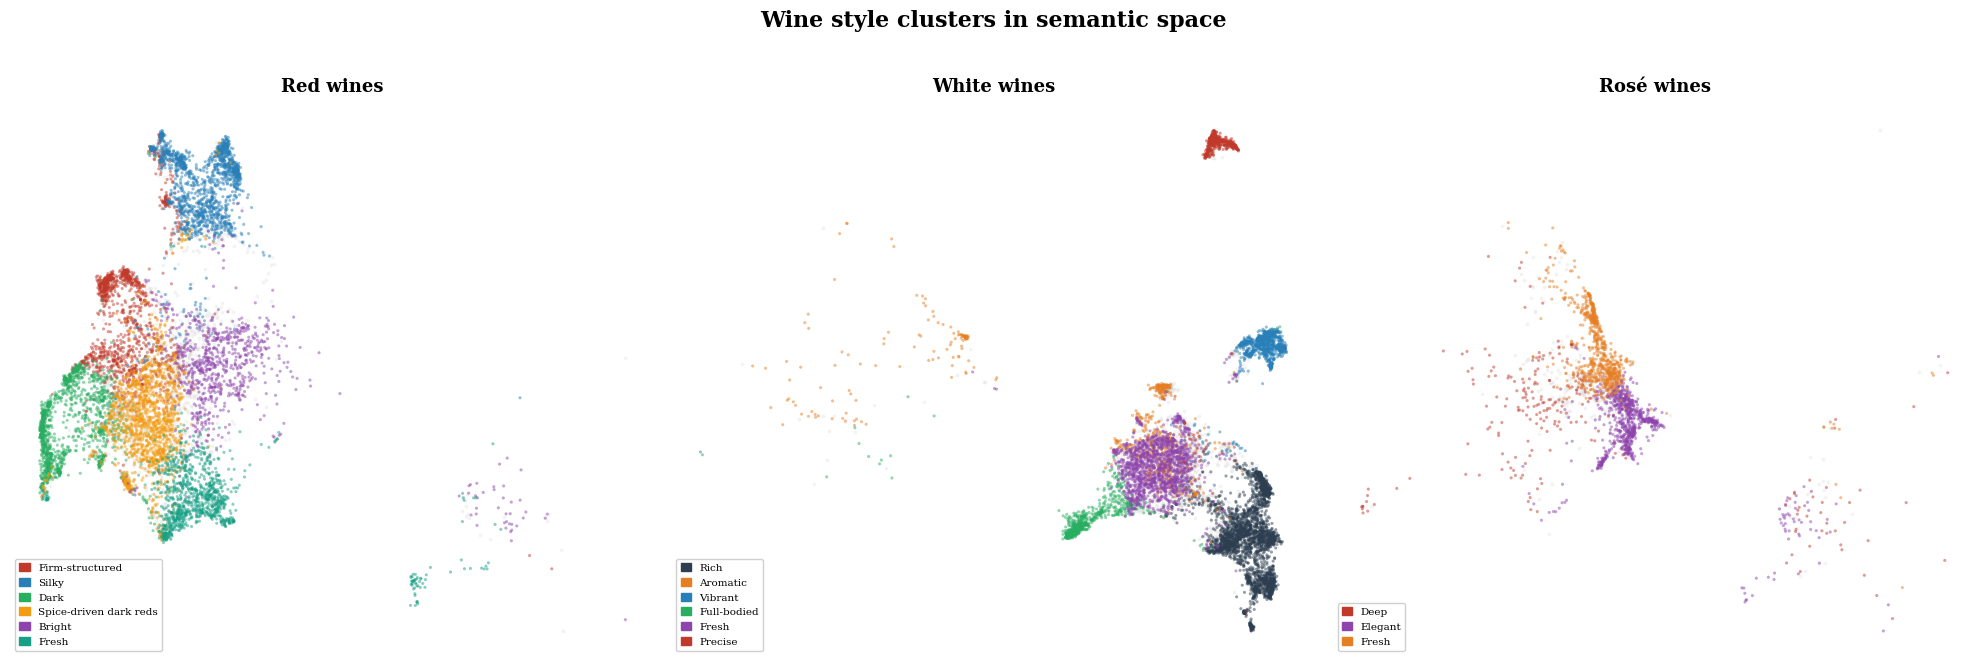

Saved: results/figures/04_umap_combined.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

for ax, df, short_labels, palette, title in [
    (axes[0], df_red,   RED_SHORT,   RED_PALETTE,   'Red wines'),
    (axes[1], df_white, WHITE_SHORT, WHITE_PALETTE, 'White wines'),
    (axes[2], df_rose,  ROSE_SHORT,  ROSE_PALETTE,  'Rosé wines'),
]:
    noise = df['cluster'] == -1
    ax.scatter(df.loc[noise, 'umap_x'], df.loc[noise, 'umap_y'],
               c=NOISE_COLOR, s=3, alpha=0.25, rasterized=True, zorder=1)
    handles = []
    for cluster_id, label in sorted(short_labels.items()):
        mask  = df['cluster'] == cluster_id
        color = palette[cluster_id % len(palette)]
        ax.scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                   c=color, s=5, alpha=0.5, rasterized=True, zorder=2, edgecolors='none')
        handles.append(mpatches.Patch(color=color, label=label))
    ax.legend(handles=handles, loc='lower left', fontsize=7.5,
              frameon=True, framealpha=0.92, edgecolor='#ccc',
              handlelength=1, handleheight=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Wine style clusters in semantic space', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/figures/04_umap_combined.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: results/figures/04_umap_combined.png')


## 4. Cluster cards

One card per cluster — style name + key descriptors as tags + top example wines.

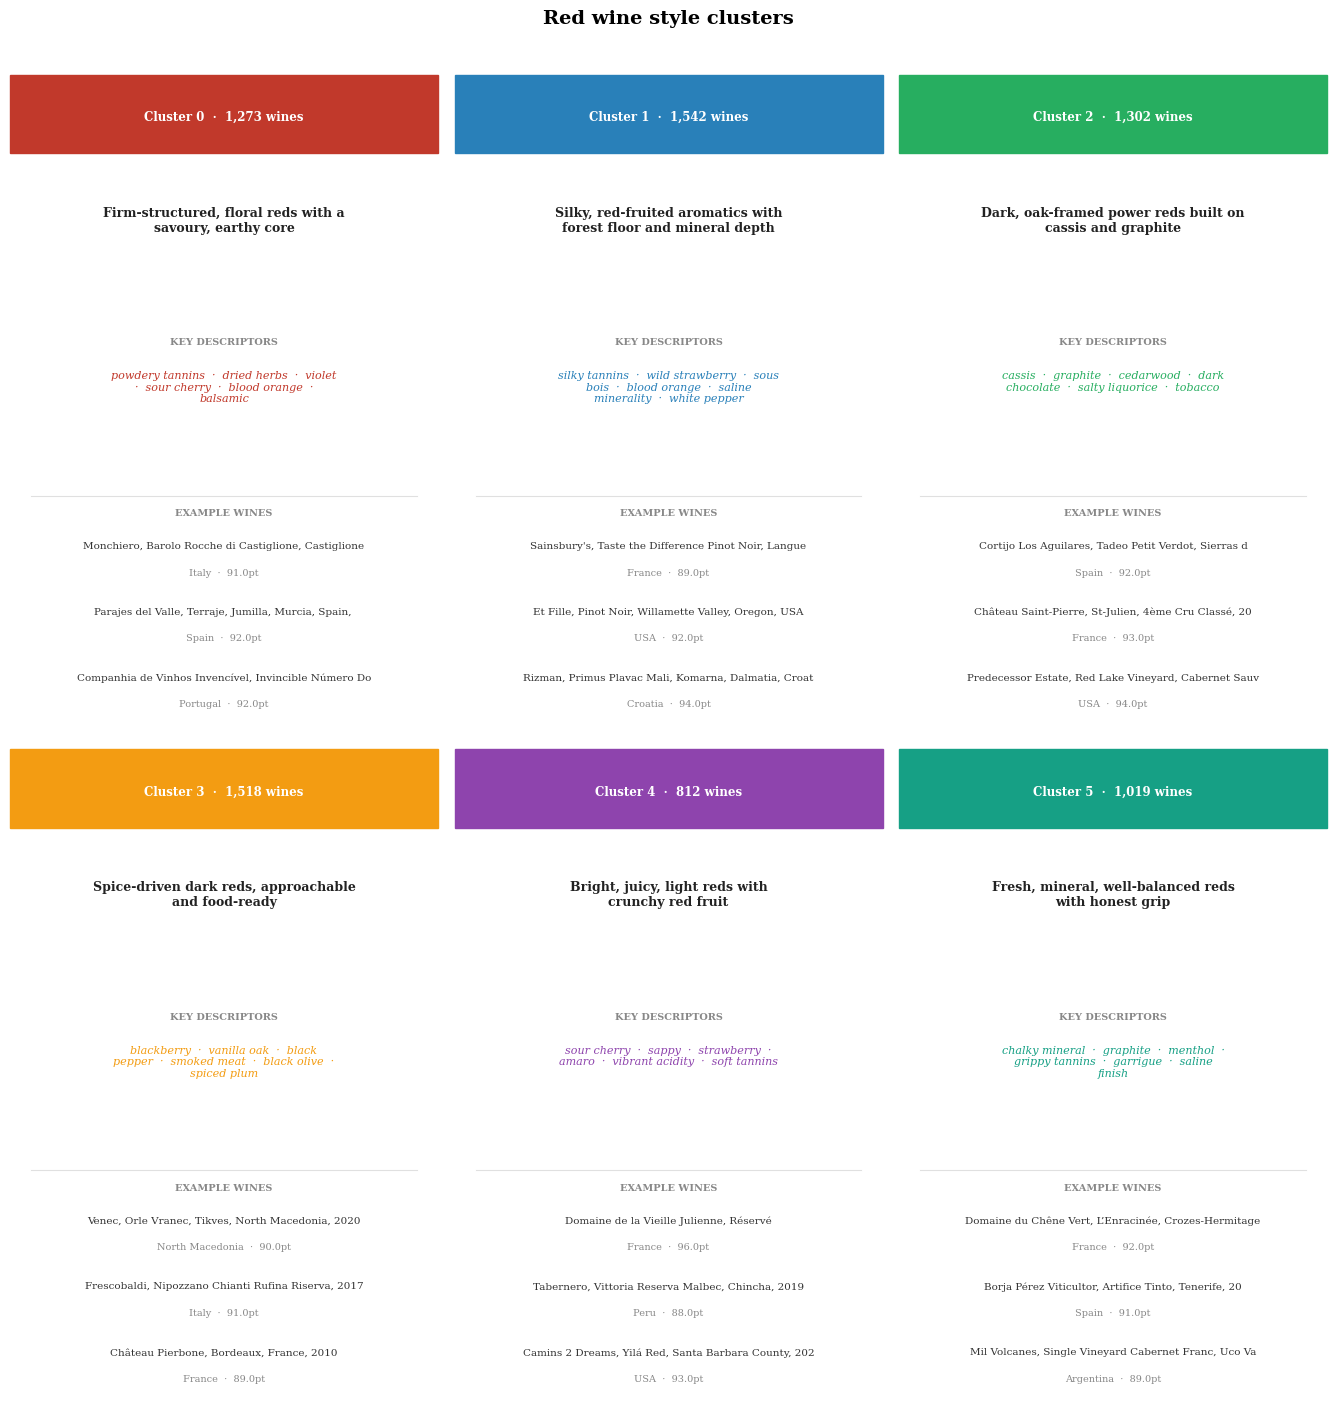

Saved: results/figures/04_cards_red.png


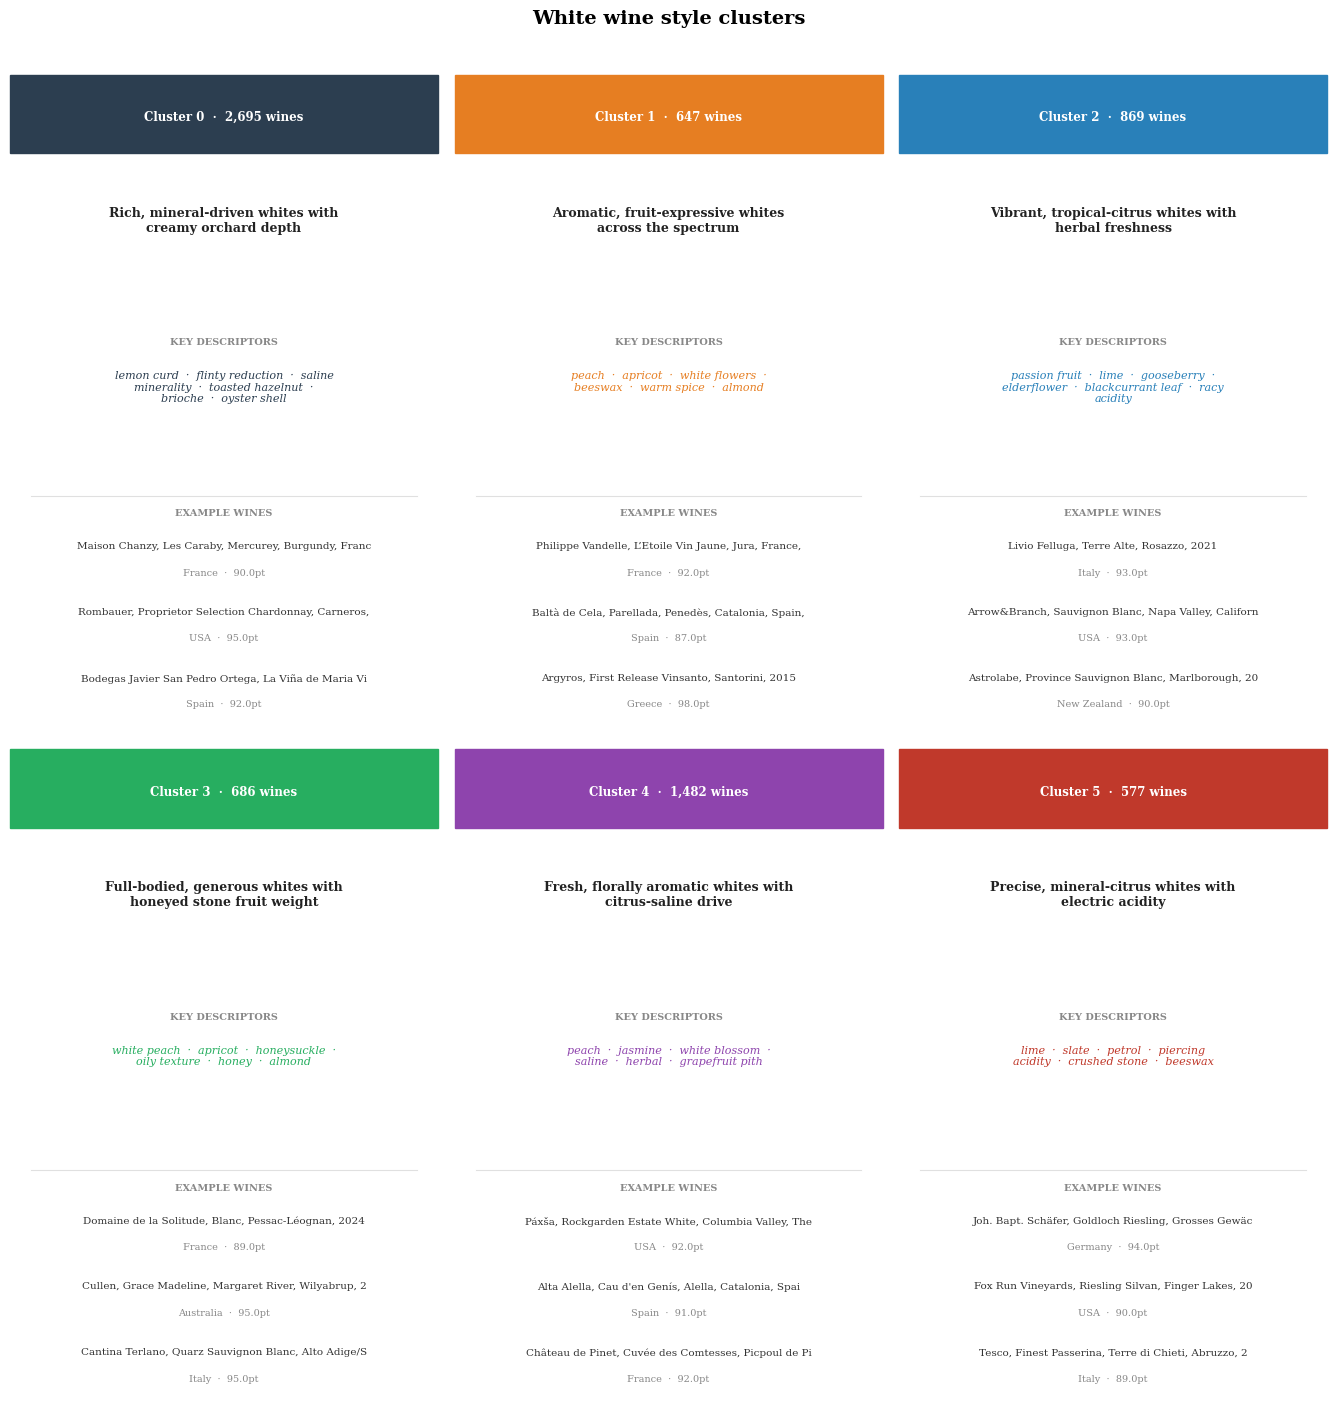

Saved: results/figures/04_cards_white.png


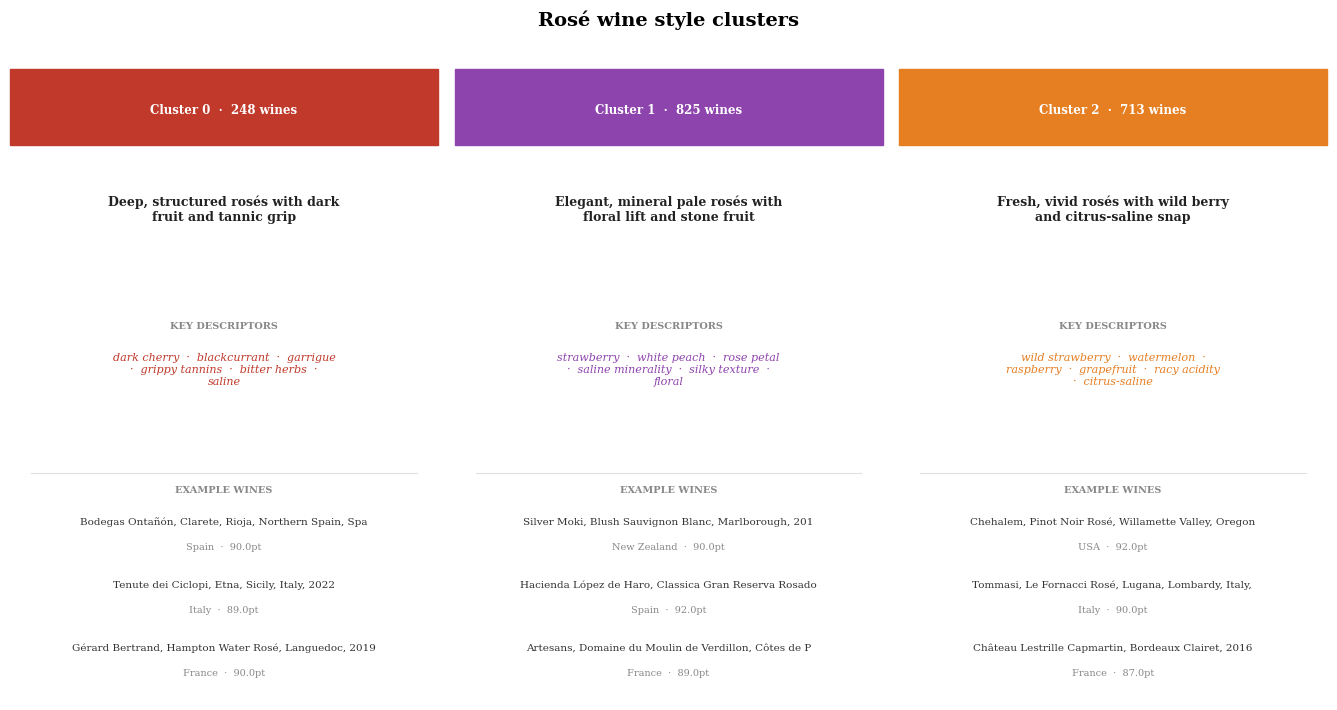

Saved: results/figures/04_cards_rose.png


In [7]:
def get_example_wines(df, cluster_id, n=3):
    """Return n diverse example wines from a cluster."""
    subset = df[df['cluster'] == cluster_id].copy()
    if len(subset) == 0:
        return []
    selected, used_countries = [], set()
    subset = subset.sample(frac=1, random_state=42).reset_index(drop=True)
    for _, wine in subset.iterrows():
        if len(selected) >= n: break
        if wine['Country'] not in used_countries:
            selected.append(wine)
            used_countries.add(wine['Country'])
    for _, wine in subset.iterrows():
        if len(selected) >= n: break
        if not any(wine['title'] == s['title'] for s in selected):
            selected.append(wine)
    return selected


def draw_card(ax, cid, color, label, descs, size, wines):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Colour header bar
    ax.add_patch(plt.Rectangle((0, 0.88), 1, 0.12, color=color,
                               transform=ax.transAxes, clip_on=False))
    ax.text(0.5, 0.935, f'Cluster {cid}  ·  {size:,} wines',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')

    # Style name
    wrapped = textwrap.fill(label, width=36)
    ax.text(0.5, 0.80, wrapped,
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, fontweight='bold', color='#222',
            multialignment='center')

    # Descriptor tags
    ax.text(0.5, 0.60, 'KEY DESCRIPTORS',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7, color='#888', fontweight='bold')
    tag_text = '  ·  '.join(descs[:6])
    wrapped_tags = textwrap.fill(tag_text, width=42)
    ax.text(0.5, 0.55, wrapped_tags,
            transform=ax.transAxes, ha='center', va='top',
            fontsize=8, color=color, style='italic',
            multialignment='center')

    # Divider
    ax.plot([0.05, 0.95], [0.36, 0.36], color='#e0e0e0', linewidth=0.8,
            transform=ax.transAxes)

    # Example wines
    ax.text(0.5, 0.34, 'EXAMPLE WINES',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7, color='#888', fontweight='bold')
    y_pos = 0.29
    for wine in wines:
        title_short = str(wine['title'])[:52]
        score = wine['score'] if pd.notna(wine['score']) else '–'
        ax.text(0.5, y_pos, title_short,
                transform=ax.transAxes, ha='center', va='top',
                fontsize=7.5, color='#333')
        ax.text(0.5, y_pos - 0.04,
                f"{wine['Country']}  ·  {score}pt",
                transform=ax.transAxes, ha='center', va='top',
                fontsize=7, color='#888')
        y_pos -= 0.10

    # Card border
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('#e0e0e0')
        ax.spines[spine].set_linewidth(0.8)


def plot_cluster_cards(df, labels, descriptors, palette, colour_name, fname, cols=3):
    cluster_ids = sorted(labels.keys())
    n = len(cluster_ids)
    rows = (n + cols - 1) // cols  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 7 * rows))

    # Normalise axes to always be 2D array
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    for idx, cid in enumerate(cluster_ids):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        draw_card(
            ax, cid,
            color=palette[cid % len(palette)],
            label=labels[cid],
            descs=descriptors[cid],
            size=len(df[df['cluster'] == cid]),
            wines=get_example_wines(df, cid, n=3),
        )

    # Hide unused axes
    for idx in range(n, rows * cols):
        row, col = divmod(idx, cols)
        axes[row][col].axis('off')

    plt.suptitle(f'{colour_name} wine style clusters',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


plot_cluster_cards(df_red,   RED_LABELS,   RED_DESCRIPTORS,   RED_PALETTE,
                  'Red',   'results/figures/04_cards_red.png',   cols=3)
plot_cluster_cards(df_white, WHITE_LABELS, WHITE_DESCRIPTORS, WHITE_PALETTE,
                  'White', 'results/figures/04_cards_white.png', cols=3)
plot_cluster_cards(df_rose,  ROSE_LABELS,  ROSE_DESCRIPTORS,  ROSE_PALETTE,
                  'Rosé',  'results/figures/04_cards_rose.png',  cols=3)

## 5. Cluster size comparison

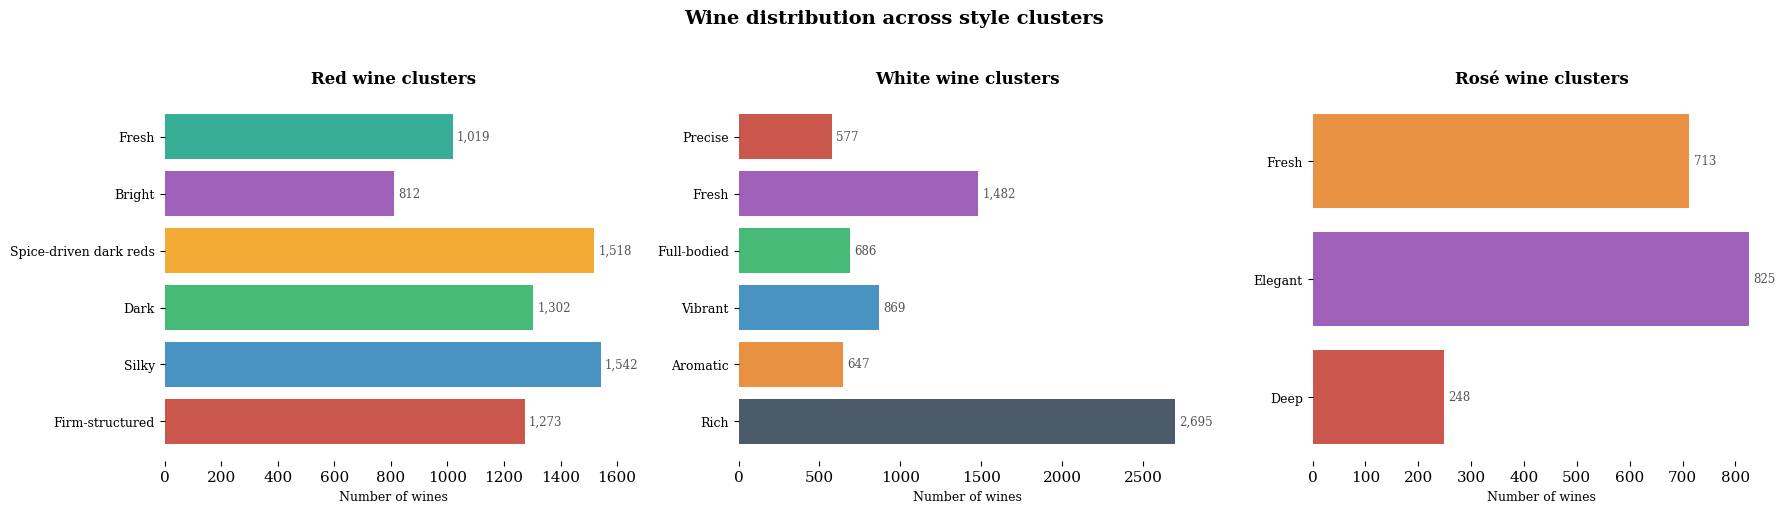

Saved: results/figures/04_cluster_sizes.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df_c, labels, palette, title in [
    (axes[0], df_red,   RED_LABELS,   RED_PALETTE,   'Red wine clusters'),
    (axes[1], df_white, WHITE_LABELS, WHITE_PALETTE, 'White wine clusters'),
    (axes[2], df_rose,  ROSE_LABELS,  ROSE_PALETTE,  'Rosé wine clusters'),
]:
    cluster_ids = sorted(labels.keys())
    sizes  = [len(df_c[df_c['cluster'] == cid]) for cid in cluster_ids]
    colors = [palette[cid % len(palette)] for cid in cluster_ids]
    shorts = [labels[cid].split(',')[0] for cid in cluster_ids]

    bars = ax.barh(range(len(cluster_ids)), sizes, color=colors, alpha=0.85)
    ax.set_yticks(range(len(cluster_ids)))
    ax.set_yticklabels(shorts, fontsize=9)
    ax.set_xlabel('Number of wines', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, size in zip(bars, sizes):
        ax.text(bar.get_width() + max(sizes) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{size:,}', va='center', fontsize=8.5, color='#555')

plt.suptitle('Wine distribution across style clusters',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/figures/04_cluster_sizes.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: results/figures/04_cluster_sizes.png')


---

## Summary

| Figure | File |
|--------|------|
| UMAP Red | `04_umap_red.png` |
| UMAP White | `04_umap_white.png` |
| UMAP Rosé | `04_umap_rose.png` |
| UMAP Combined | `04_umap_combined.png` |
| Cluster cards Red | `04_cards_red.png` |
| Cluster cards White | `04_cards_white.png` |
| Cluster cards Rosé | `04_cards_rose.png` |
| Cluster sizes | `04_cluster_sizes.png` |

**Next:** article draft — `reports/article_draft.md`
